### Check to make sure the right environment is used and GPU is available

In [7]:
import torch
import sys
print("My environment:", sys.executable)
print("Do I have access to my GPU?", torch.cuda.is_available())
print("My GPU:", torch.cuda.get_device_name(0))


ModuleNotFoundError: No module named 'torch'

In [20]:
import torch
print(torch.__version__)
print(torch.version.cuda)      # Shows which CUDA PyTorch was compiled with
print(torch.backends.cudnn.enabled)
print(torch.cuda.is_available())

2.6.0
None
True
False


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
raw_df = pd.read_csv("/home/abbie/projects/TECH646-Haptic-Results/data/raw_data.csv")

raw_df.set_index('subject', inplace=True)

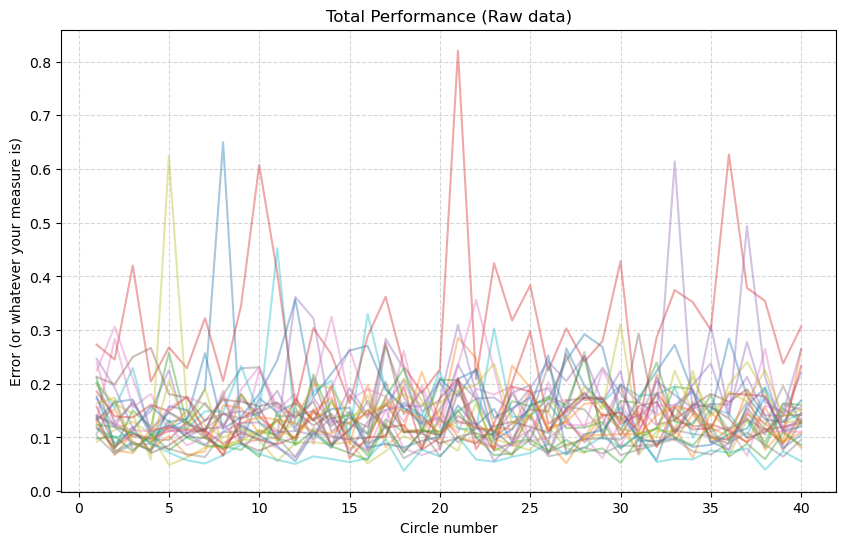

In [8]:
plt.figure(figsize=(10, 6))
for i, row in raw_df.iterrows():
    plt.plot(range(1, 41), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Raw data)")
plt.xlabel("Circle number")
plt.ylabel("Error (or whatever your measure is)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [9]:
z_scores = (raw_df - raw_df.mean()) / raw_df.std()

# Replace values with NaN if they’re more than 1 standard deviations from the mean
df_clean = raw_df.mask(np.abs(z_scores) > 1)

# Optional: fill NaN with the median of that column instead of dropping
df_clean = df_clean.apply(lambda x: x.fillna(x.median()), axis=0)



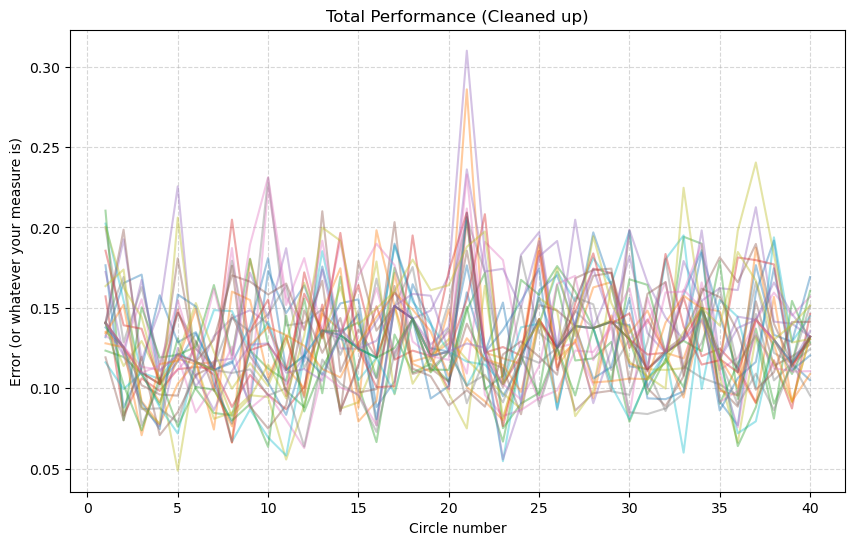

In [10]:
plt.figure(figsize=(10, 6))
for i, row in df_clean.iterrows():
    plt.plot(range(1, 41), row.values, alpha=0.4)  # faint line for each subject

plt.title("Total Performance (Cleaned up)")
plt.xlabel("Circle number")
plt.ylabel("Error (or whatever your measure is)")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

In [11]:
window_sizes = [4, 8, 16, 20, 40]

slopes_dict = {}  # to store slopes for each window

for window in window_sizes:
    all_slopes = []
    for i, row in df_clean.iterrows():
        errors = row.values
        for start in range(len(errors) - window + 1):
            window_vals = errors[start:start+window]
            x = np.arange(window)
            
            # Skip flat windows (all values identical)
            if np.all(window_vals == window_vals[0]):
                slope = 0.0
            else:
                slope = np.polyfit(x, window_vals, 1)[0]
            
            all_slopes.append(slope)
    
    slopes_dict[window] = np.array(all_slopes)

In [14]:
from sklearn.mixture import GaussianMixture
from scipy.stats import norm

def find_intersection(mu1, sigma1, mu2, sigma2):
    # Numerical intersection of two 1D Gaussians
    x = np.linspace(min(mu1, mu2) - 3*max(sigma1, sigma2),
                    max(mu1, mu2) + 3*max(sigma1, sigma2), 10000)
    p1 = norm.pdf(x, mu1, sigma1)
    p2 = norm.pdf(x, mu2, sigma2)
    idx = np.argwhere(np.diff(np.sign(p1 - p2))).flatten()
    return x[idx]

thresholds = {}

for window, slopes in slopes_dict.items():
    slopes_reshaped = slopes.reshape(-1, 1)
    gmm = GaussianMixture(n_components=3, random_state=42)
    gmm.fit(slopes_reshaped)
    
    means = np.sort(gmm.means_.flatten())
    sigmas = np.sqrt(np.sort(gmm.covariances_.flatten()))
    
    t1 = find_intersection(means[0], sigmas[0], means[1], sigmas[1])[0]
    t2 = find_intersection(means[1], sigmas[1], means[2], sigmas[2])[0]
    
    thresholds[window] = {"learning_nothing": t1, "nothing_fatigue": t2}

# Display thresholds per window
for w, t in thresholds.items():
    print(f"Window {w}: Learning–Nothing = {t['learning_nothing']:.4f}, Nothing–Fatigue = {t['nothing_fatigue']:.4f}")


Window 4: Learning–Nothing = -0.0058, Nothing–Fatigue = 0.0071
Window 8: Learning–Nothing = -0.0015, Nothing–Fatigue = 0.0032
Window 16: Learning–Nothing = -0.0000, Nothing–Fatigue = 0.0014
Window 20: Learning–Nothing = 0.0002, Nothing–Fatigue = 0.0008
Window 40: Learning–Nothing = 0.0003, Nothing–Fatigue = 0.0003


In [13]:
window = 4  # size of sliding window
threshold = 0.01  # slope threshold to classify changes

modes_list = []

for i, row in df_clean.iterrows():
    subject_modes = []
    errors = row.values
    for start in range(len(errors) - window + 1):
        window_vals = errors[start:start+window]
        x = np.arange(window)
        # Linear regression: slope = change per trial
        slope = np.polyfit(x, window_vals, 1)[0]
        
        if slope < -threshold:
            subject_modes.append("learning")
        # elif slope > threshold:
        #     subject_modes.append("fatigued")
        else:
            subject_modes.append("nothing")
    
    # Pad the beginning so the mode array is same length as trials
    subject_modes = ["nothing"]*(window-1) + subject_modes
    modes_list.append(subject_modes)

# Convert to DataFrame for easy handling
modes_df = pd.DataFrame(modes_list, index=df_clean.index, columns=df_clean.columns)

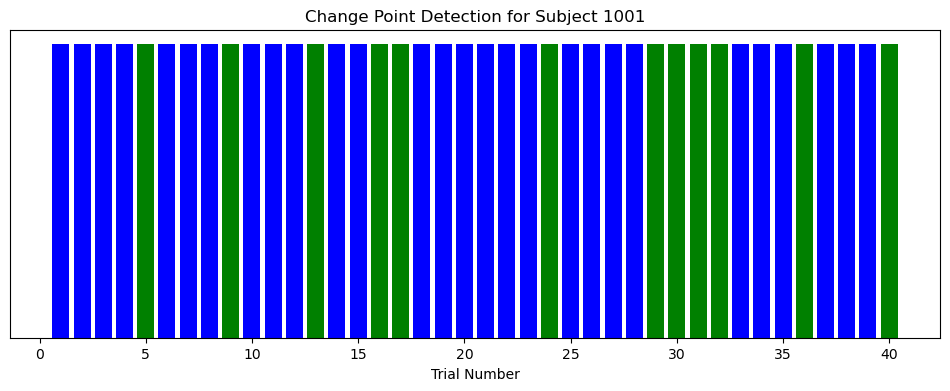

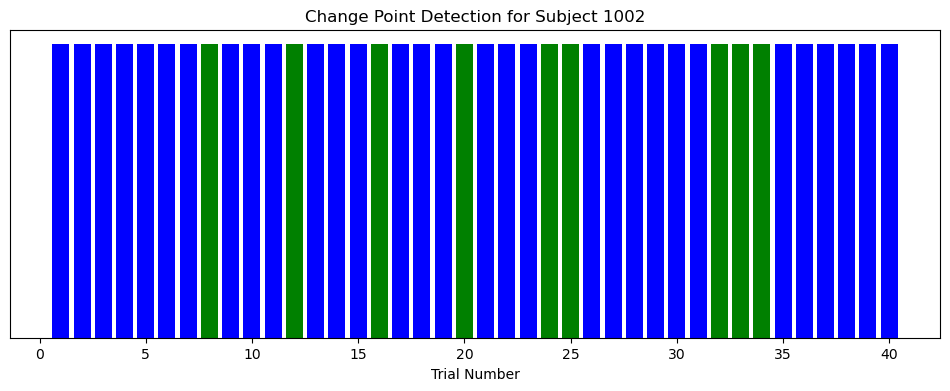

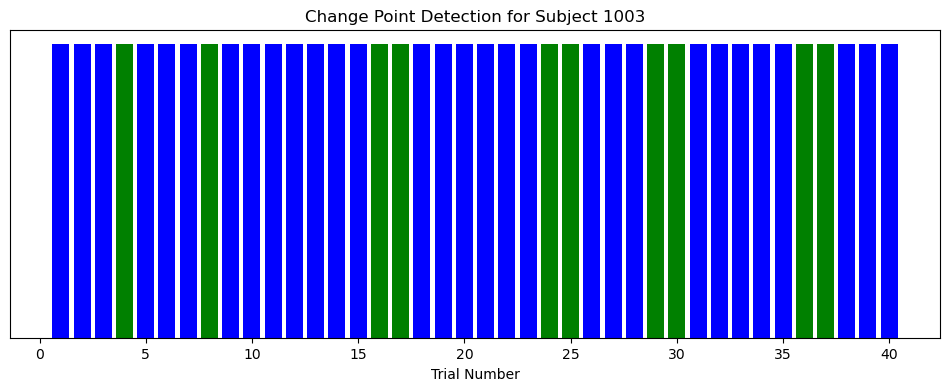

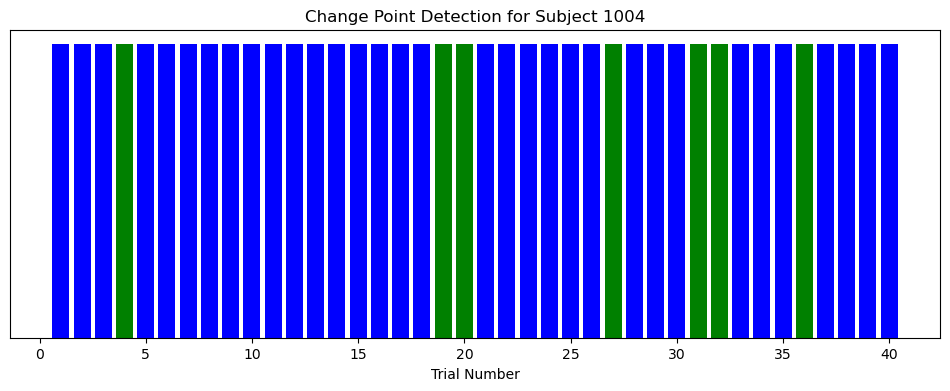

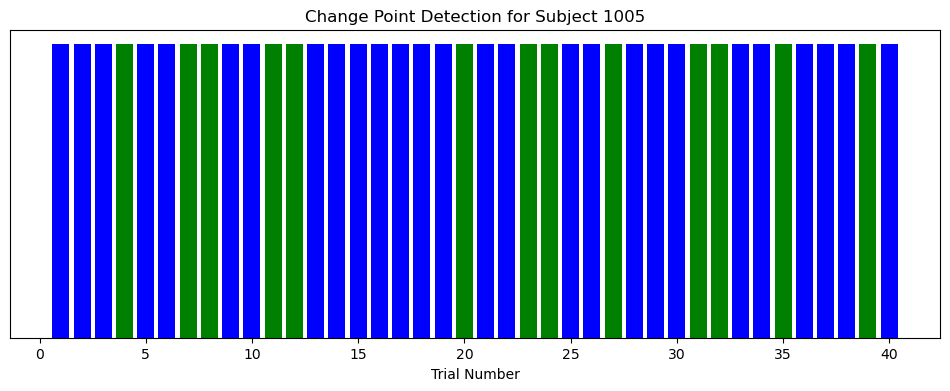

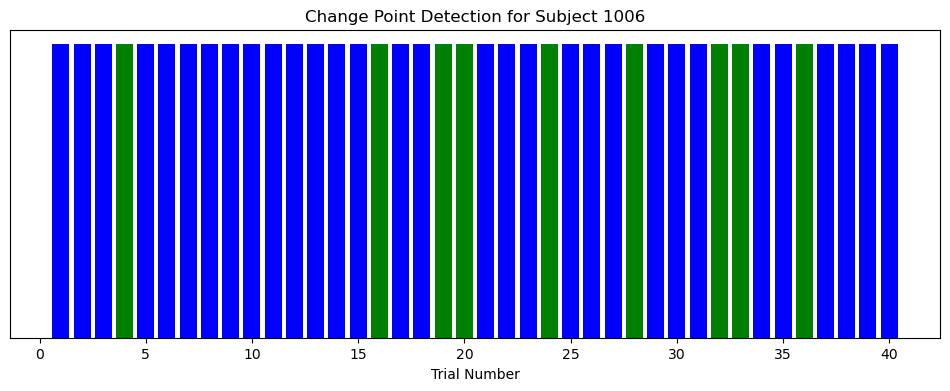

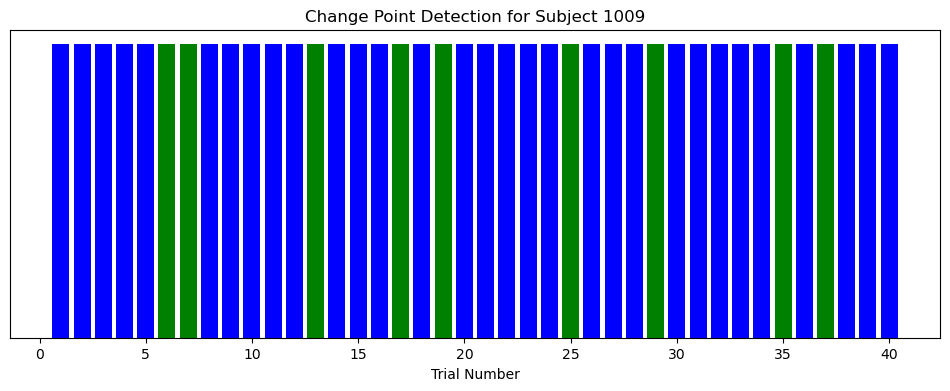

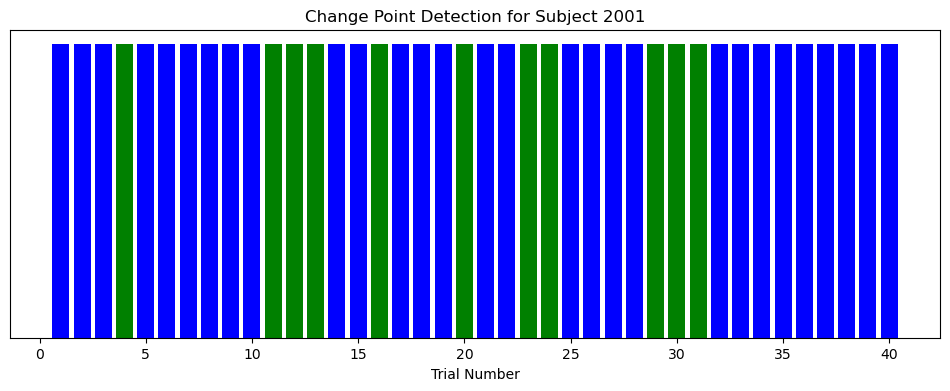

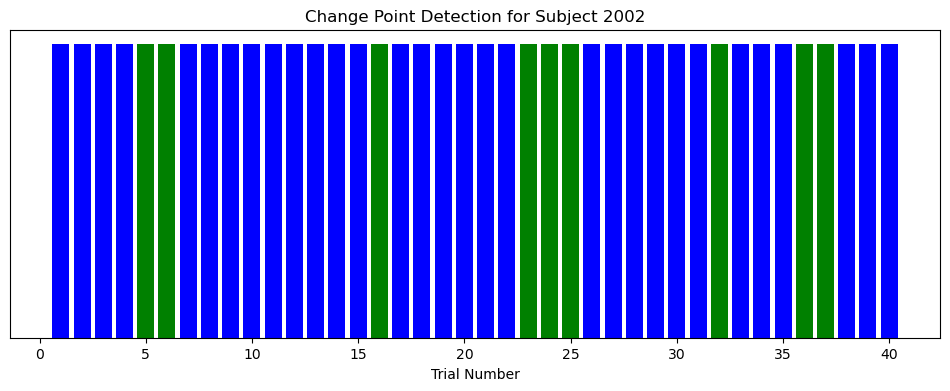

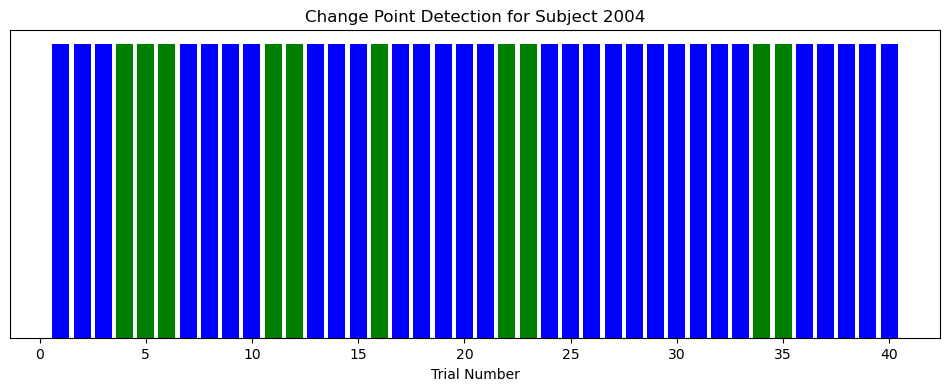

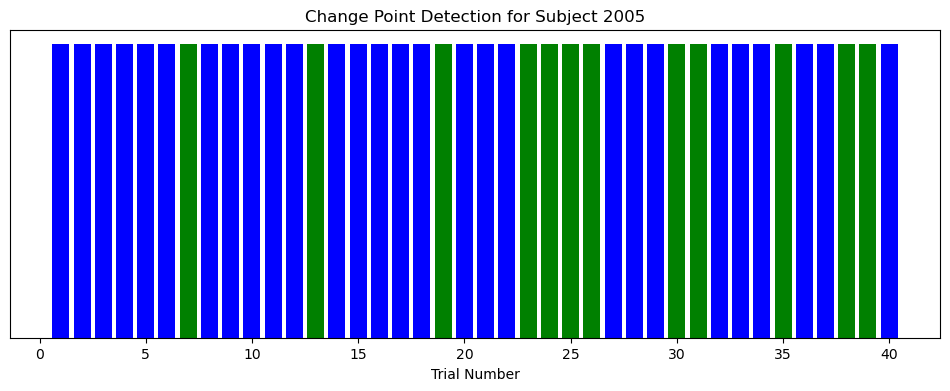

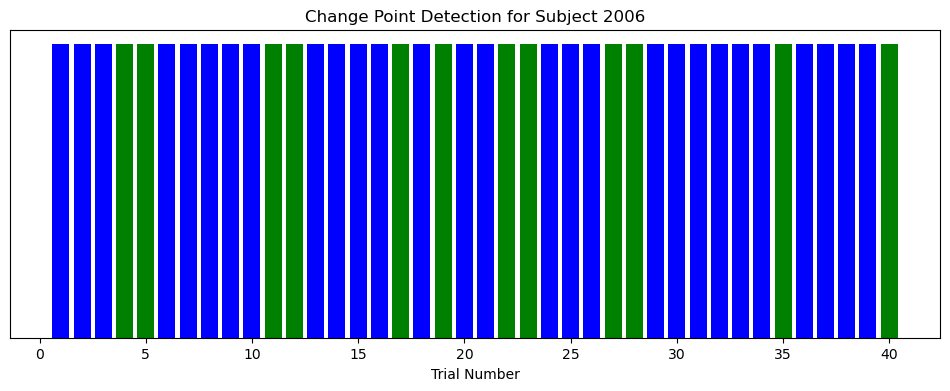

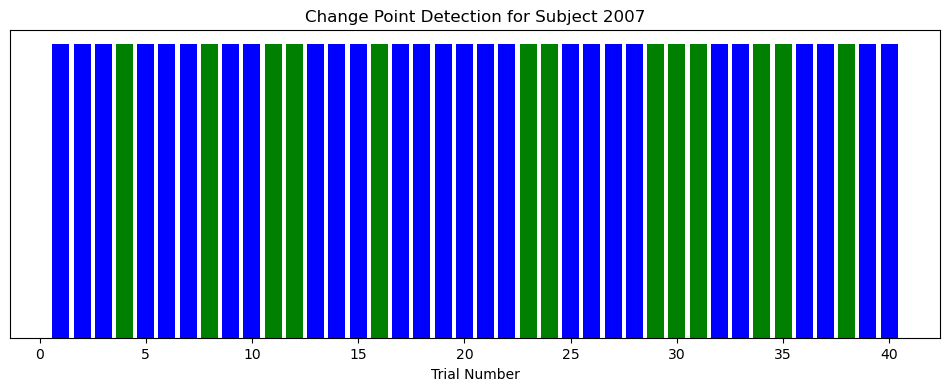

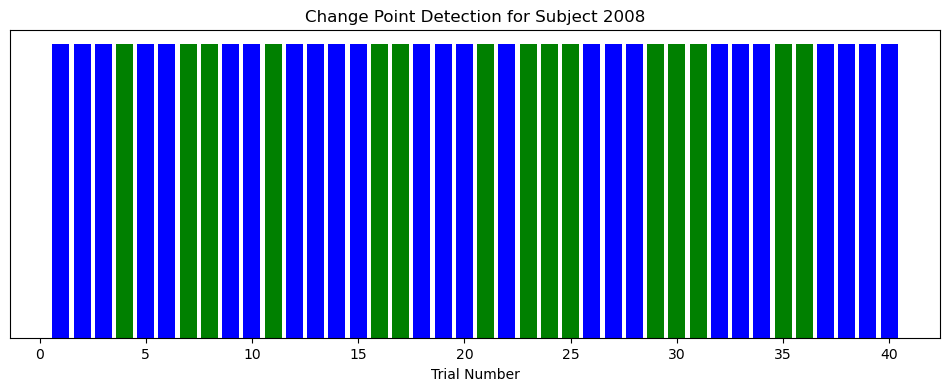

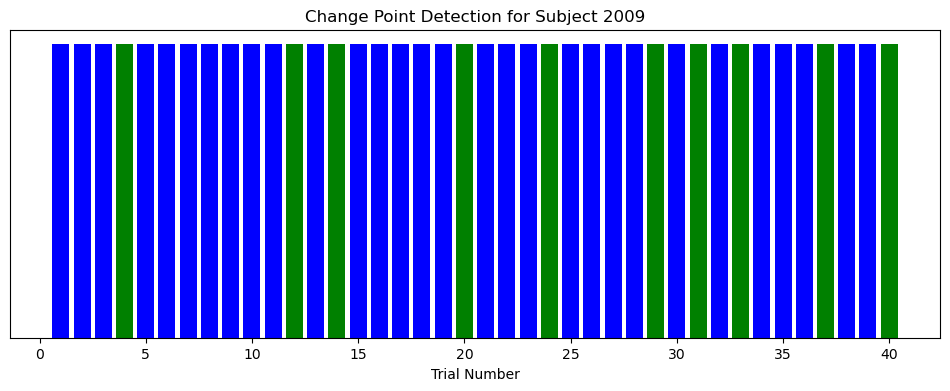

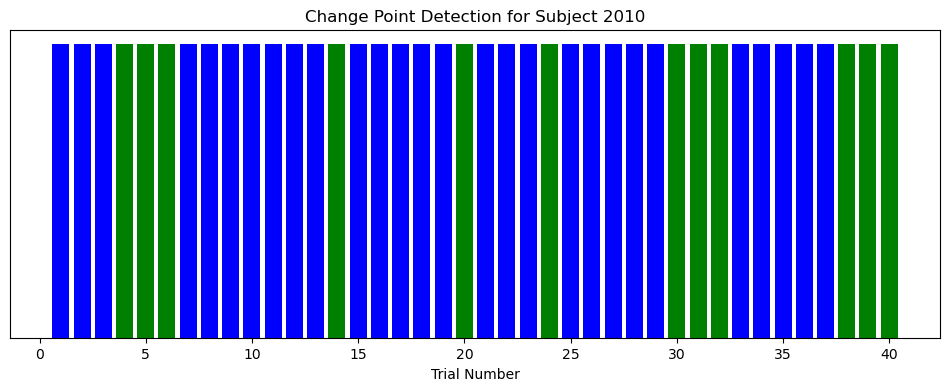

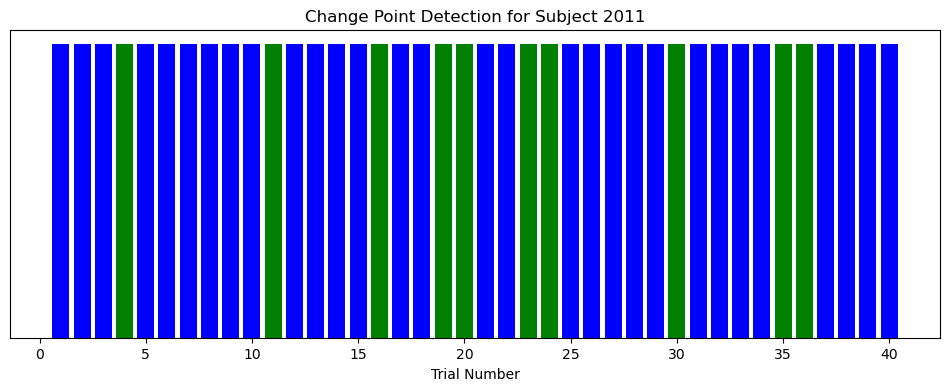

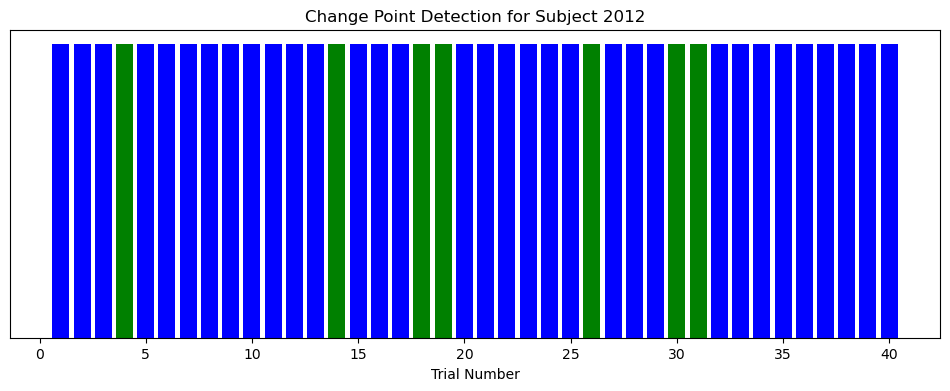

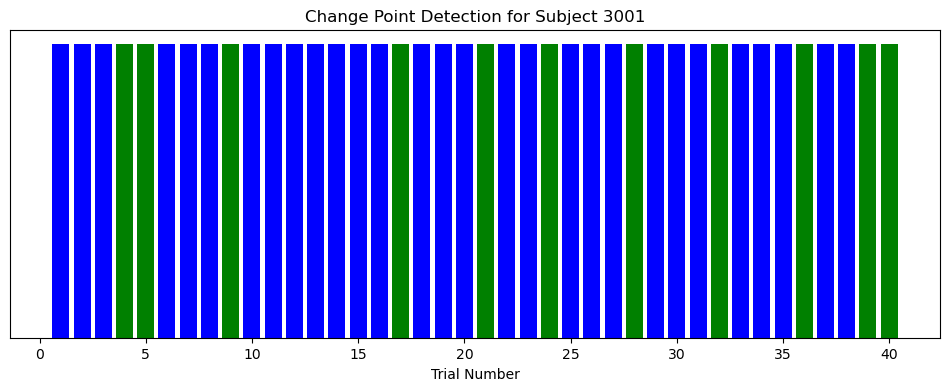

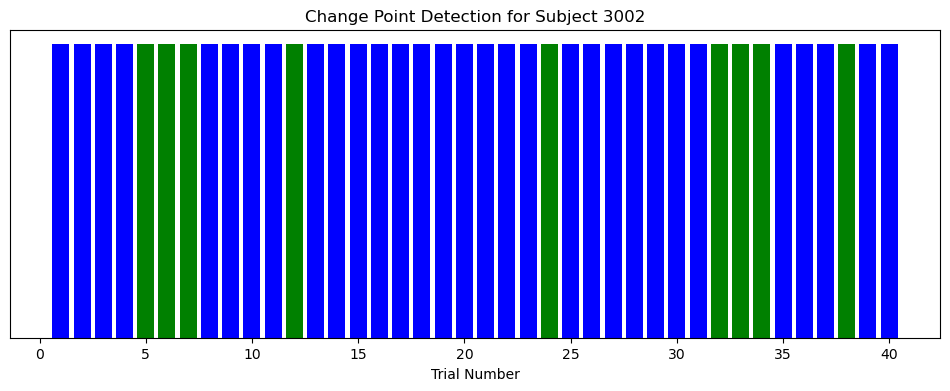

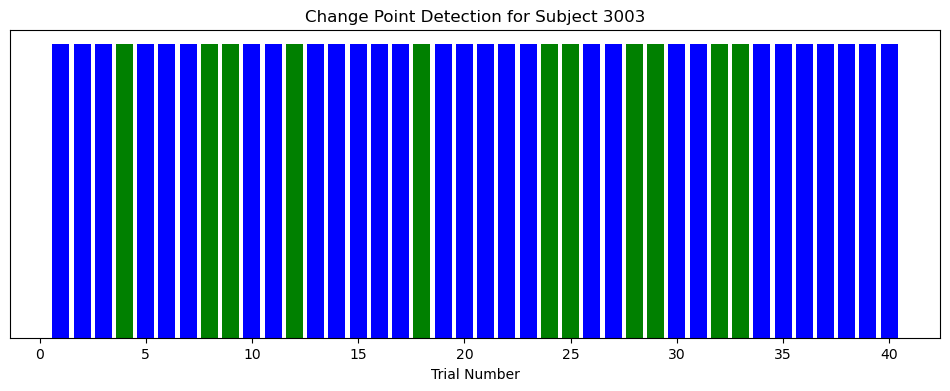

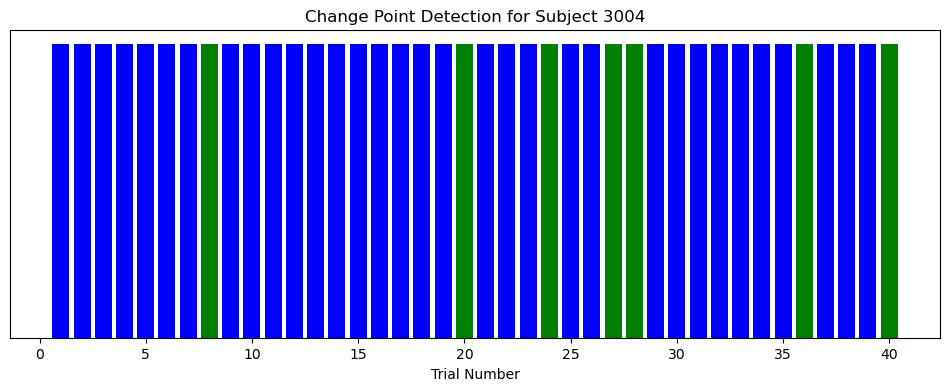

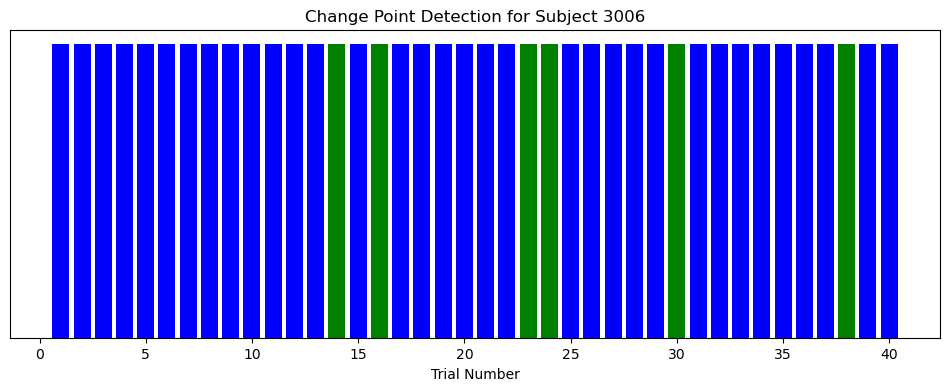

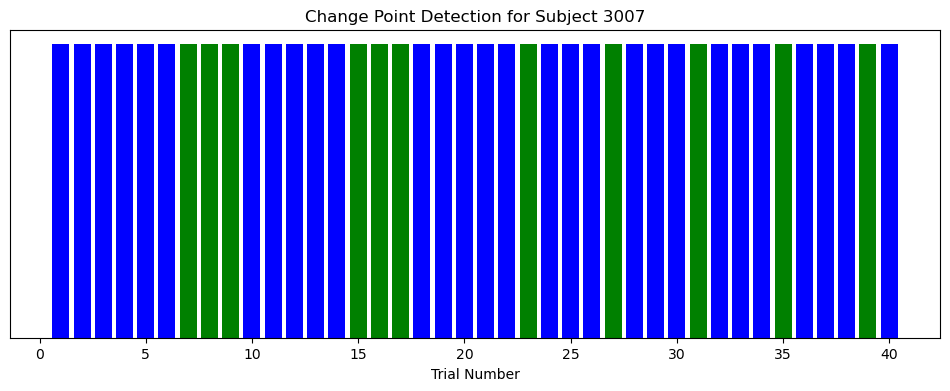

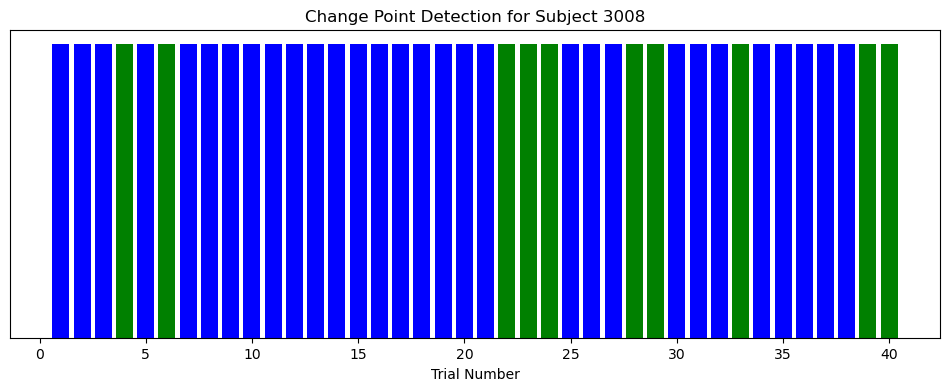

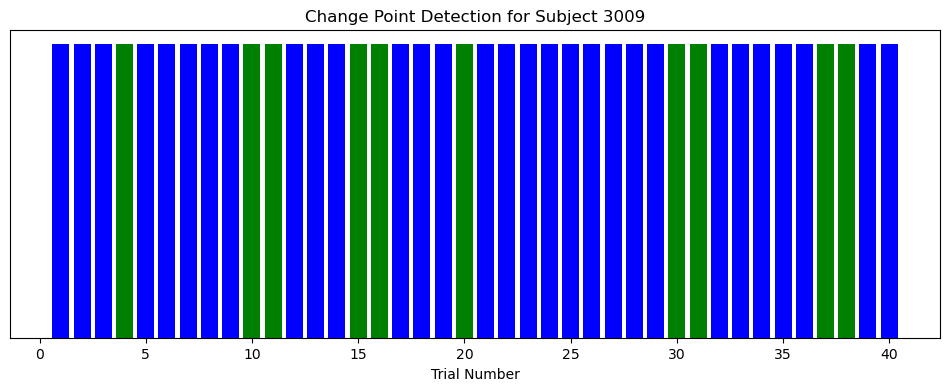

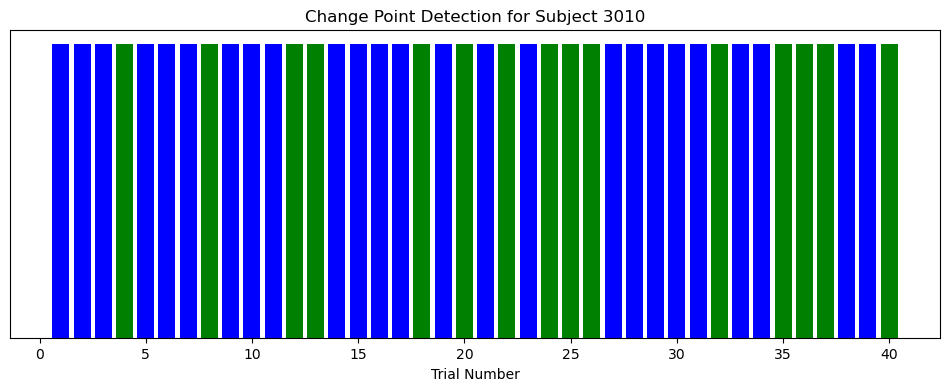

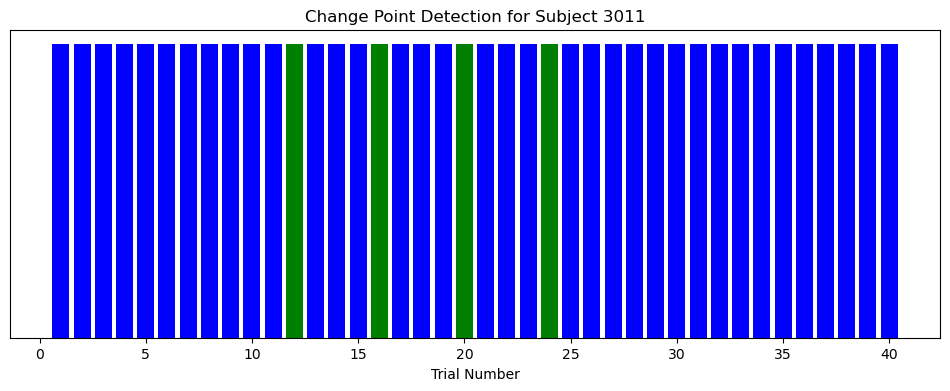

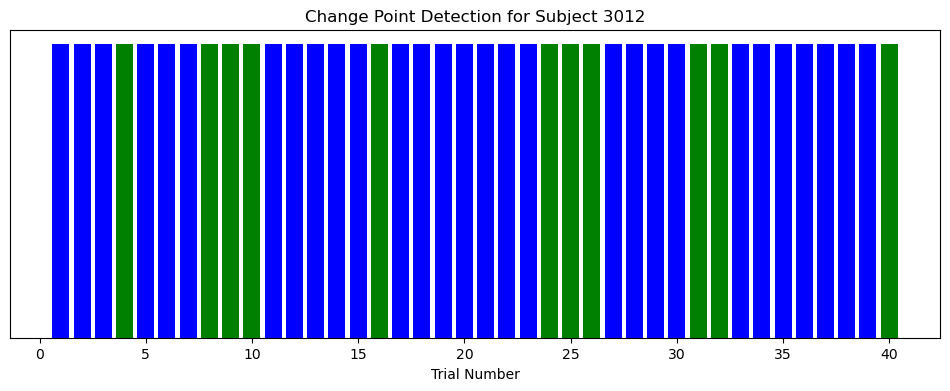

In [117]:
for i in range(0,29):
    subject = i
    # colors = {"learning": "green", "nothing": "blue", "fatigued": "red"}
    colors = {"learning": "green", "nothing": "blue"}
    modes = modes_df.iloc[subject]

    plt.figure(figsize=(12,4))
    for i, mode in enumerate(modes):
        plt.bar(i+1, 1, color=colors[mode])

    plt.title(f"Change Point Detection for Subject {df_clean.index[subject]}")
    plt.xlabel("Trial Number")
    plt.yticks([])
    plt.show()